In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt
import torch
import numpy as np
from torchvision.utils import make_grid
from tqdm import tqdm
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
device

In [ ]:
transform = transforms.ToTensor()
trainset = torchvision.datasets.MNIST("./data", train=True, transform=transform, download=True)

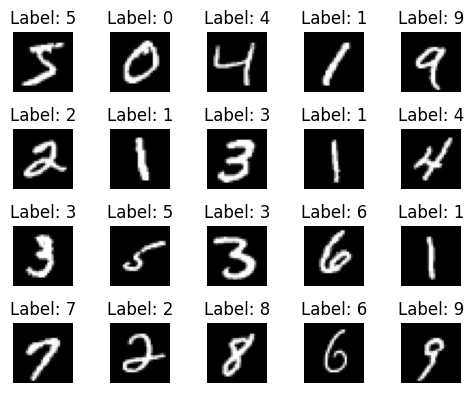

In [ ]:
def show_images(dataset, num_samples=20, cols=4):
    plt.figure(figsize=(5, 5))
    for i, (img, label) in enumerate(dataset):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols) + 1, cols, i + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_images(trainset, num_samples=20, cols=5)

# GAN

In [ ]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

In [ ]:
latent_dim = 100
lr = 2e-4

In [ ]:
class Generator(nn.Module):
  def __init__(self, latent_dim):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(latent_dim, 64 * 7 * 7),
        nn.ReLU(),
        nn.Unflatten(1, (64, 7, 7)),
        nn.Upsample(scale_factor=2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.Upsample(scale_factor=2),
        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(256),
        nn.Conv2d(256, 1, kernel_size=3, padding=1),
        nn.Tanh()
    )

  def forward(self, X):
    return self.model(X)


In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()

    self.model = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3, padding=1),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.BatchNorm2d(128),
        nn.Flatten(),
        nn.Linear(128 * 7 * 7, 1),
        nn.Sigmoid()
    )

  def forward(self, X):
    return self.model(X)

In [ ]:
from numpy import kron
g = Generator(latent_dim).to(device)
d = Discriminator().to(device)

lossFn = nn.BCELoss()

optimG = torch.optim.Adam(g.parameters(), lr=lr)
optimD = torch.optim.Adam(d.parameters(), lr=lr)

In [ ]:
g.train()
for epoch in range(30):
  meanLossD = 0
  meanLossG = 0

  for i, (X, y) in enumerate(tqdm(trainloader)):
    realImg = X.to(device)
    realLabel = torch.ones(realImg.size(0), 1, device=device)
    fakeLabels = torch.zeros(realImg.size(0), 1, device=device)
    latentVec = torch.randn(realImg.size(0), latent_dim, device=device)

    # Discriminator training
    optimD.zero_grad()
    realLoss = lossFn(d(realImg), realLabel)
    fakeLoss = lossFn(d(g(latentVec).detach()), fakeLabels)
    lossD = (realLoss + fakeLoss) / 2
    meanLossD += lossD
    lossD.backward()
    optimD.step()

    # Generator training
    optimG.zero_grad()
    lossG = lossFn(d(g(latentVec)), realLabel)
    meanLossG += lossG
    lossG.backward()
    optimG.step()

  print(f"Epoch {epoch}: D loss = {meanLossD / len(trainloader)}, G loss = {meanLossG / len(trainloader)}")



100%|██████████| 938/938 [00:31<00:00, 29.50it/s]


Epoch 0: D loss = 0.15354523062705994, G loss = 3.0296430587768555


100%|██████████| 938/938 [00:32<00:00, 29.01it/s]


Epoch 1: D loss = 0.2107652872800827, G loss = 3.042637586593628


100%|██████████| 938/938 [00:31<00:00, 29.44it/s]


...

Epoch 27: D loss = 0.12328001111745834, G loss = 7.869138717651367


100%|██████████| 938/938 [00:31<00:00, 29.61it/s]


Epoch 28: D loss = 0.129172682762146, G loss = 7.520148754119873


100%|██████████| 938/938 [00:31<00:00, 29.60it/s]

Epoch 29: D loss = 0.12825579941272736, G loss = 6.978818893432617


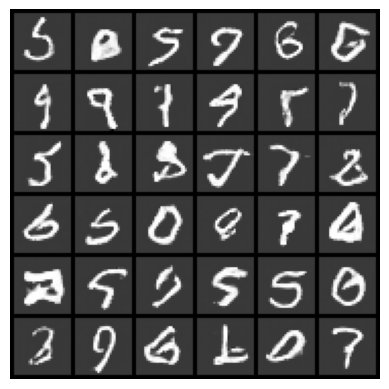

In [ ]:
z = torch.randn(36, latent_dim, device=device)
generated = g(z).detach().cpu()
grid = torchvision.utils.make_grid(generated, nrow=6, normalize=True)
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis("off")
plt.show()

In [ ]:
#torch.save(g.state_dict(), "/content/gdrive/My Drive/Colab Notebooks/Learning/mnistGANmodelWeights_b")

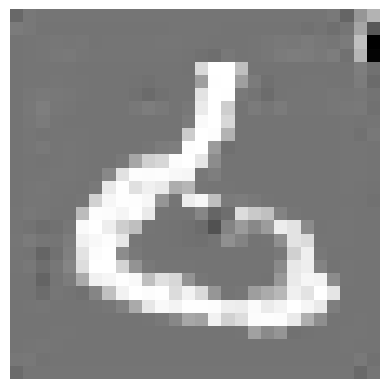

In [ ]:
#z = torch.randn(1, latent_dim, device=device)
z = torch.randn(1, latent_dim, device=device)

plt.imshow(g(z).detach().cpu()[0, 0], cmap='gray')
plt.axis("off")
plt.show()